# End-to-End Web Scraping & Analysis Project: Flipkart iPhone 17

## Project Objective
The goal of this project is to extract detailed product data of the iPhone 16 from Flipkart using web scraping techniques, clean and organize the data using Python, and analyze it through visualizations to derive valuable business insights.

---

## Workflow Overview
## `Data Collection → Data Understanding → Data Cleaning → Data Visualization → Insights`


---

## 1. Data Collection (Web Scraping)

We used Python libraries like `requests` and `BeautifulSoup` to scrape product details of iPhone 16 models from multiple pages on Flipkart.

### Key Tasks:
- Sent HTTP GET requests to Flipkart search result pages.
- Parsed the HTML response to extract:
  - Product Name
  - ROM / Storage
  - Display Type
  - Camera Specs
  - Processor Details
  - Warranty Info
  - Ratings
  - Number of Reviews
  - Price

---

## 2. Data Understanding

Once the raw data was scraped:
- We reviewed the structure of the data.
- Checked for missing fields, inconsistent formats, and irregular symbols (e.g., `\xa0`, `&`).
- Verified if all lists (columns) were of equal length and properly aligned.

---

## 3. Data Cleaning (Using Pandas & Regex)

We used the `pandas`  library to structure the data into a DataFrame and applied regular expressions for text cleaning.

### Cleaning Steps:
- Removed unwanted characters and spaces.
- Extracted rating, review count, and price using regex.
- Replaced missing or invalid entries with `NaN` for consistency.
- Converted data types (e.g., strings to floats/integers where required).

---

## 4. Data Visualization (EDA)

We used `matplotlib` and `seaborn` for creating plots to better understand and analyze the data.

### Univariate Analysis:
- Distribution of product ratings
- Most common ROM variants
- Frequency of different price points

### Bivariate Analysis:
- Relationship between ratings and number of reviews
- Price vs rating comparison

### Multivariate Analysis:
- Combined analysis of rating, price, and storage
- Heatmaps to explore correlations

---

## 5. Insights & Observations

From our analysis:
- Some variants of iPhone 16 consistently received higher ratings.
- Products with more reviews generally had higher visibility and better ratings.
- Price differences were observed across different storage configurations.

---

## Final Output

- A clean and structured dataset saved as:  
  `Flipkart_iPhone16_Specs.csv`
- Visual charts and graphs for insights
- Ready for use in dashboards, presentations, or machine learning models

---

## Tools & Libraries Used
- Python
- Requests (for HTTP requests)
- BeautifulSoup (for HTML parsing)
- Pandas (for data manipulation)
- Regex (for text extraction)
- Matplotlib & Seaborn (for data visualization)

---



In [11]:
import requests
from bs4 import BeautifulSoup

In [12]:
product_name = []
product_price = []
product_rom = []
product_display =[]
product_camera = []
product_processor =[]

In [13]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0.0.0 Safari/537.36"
}
for i in range(1,5):
    url = f"https://www.flipkart.com/search?q=iphone+17&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page={i}"
    # print(url)

    response = requests.get(url,headers= headers)
    print("page :",i, response.status_code)
    html_data = response.text
    soup = BeautifulSoup(html_data)
    
    # Extract Product Name
    name = soup.find_all("div",class_ = "RG5Slk")
    for i in name:
        product_name.append(i.text)

    # Extract Product Price
    price = soup.find_all("div",class_ = "hZ3P6w DeU9vF")
    for i in price:
        product_price.append(i.text)

    # Extract Rom, camera, display,processor
    features = soup.find_all("li",class_ = "DTBslk")
    for i in features:
        if "ROM" in i.text:
            product_rom.append(i.text)
        elif "Display" in i.text:
            product_display.append(i.text)
        elif "Camera" in i.text:
            product_camera.append(i.text)
        elif "Processor" in i.text:
            # print(i)
            product_processor.append(i.text)

    

page : 1 200
page : 2 200
page : 3 200
page : 4 200


In [14]:
print(product_name)
print("*"*50)
print(product_price)
print("*"*50)
print(product_rom)
print("*"*50)
print(product_display)
print("*"*50)
print(product_camera)
print("*"*50)
print(product_processor)

['Apple iPhone 17 (Black, 256 GB)', 'Apple iPhone 17 (White, 256 GB)', 'Apple iPhone 17 (Sage, 512 GB)', 'Apple iPhone 17 (Black, 512 GB)', 'Apple iPhone 17 (Mist Blue, 512 GB)', 'Apple iPhone 17 (White, 512 GB)', 'Apple iPhone 17 (Lavender, 512 GB)', 'Apple iPhone 17e (White, 256 GB)', 'Apple iPhone 17e (Soft Pink, 256 GB)', 'Apple iPhone 17e (Black, 256 GB)', 'Apple iPhone 17 Pro (Silver, 256 GB)', 'Apple iPhone 17 Pro (Deep Blue, 512 GB)', 'Apple iPhone 17 Pro Max (Silver, 256 GB)', 'Apple iPhone 17 Pro (Silver, 512 GB)', 'Apple iPhone 17 Pro (Cosmic Orange, 512 GB)', 'Apple iPhone 17e (White, 512 GB)', 'Apple iPhone 17 Pro Max (Silver, 1 TB)', 'Apple iPhone 17 Pro (Deep Blue, 256 GB)', 'Apple iPhone 17 Pro (Cosmic Orange, 256 GB)', 'Apple iPhone 17 Pro Max (Deep Blue, 512 GB)', 'Apple iPhone 17 Pro Max (Cosmic Orange, 256 GB)', 'Apple iPhone 17 Pro Max (Cosmic Orange, 512 GB)', 'Apple iPhone 17e (Soft Pink, 512 GB)', 'Apple iPhone 17 Pro Max (Silver, 512 GB)', 'Apple iPhone 17e (Bl

In [17]:
import pandas as pd

In [18]:
print("product_name", len(product_name))
print("*"*50)
print("product_price",len(product_price))
print("*"*50)
print("product_rom",len(product_rom))
print("*"*50)
print("product_display",len(product_display))
print("*"*50)
print("product_camera",len(product_camera))
print("*"*50)
print("product_processor",len(product_processor))

product_name 96
**************************************************
product_price 96
**************************************************
product_rom 96
**************************************************
product_display 96
**************************************************
product_camera 96
**************************************************
product_processor 87


In [19]:
min_len = min(
    len(product_name),
    len(product_price),
    len(product_rom),
    len(product_display),
    len(product_camera),
    len(product_processor)
)

df = pd.DataFrame({
    "Product Name": product_name[:min_len],
    "Price": product_price[:min_len],
    "ROM": product_rom[:min_len],
    "Display": product_display[:min_len],
    "Camera": product_camera[:min_len],
    "Processor": product_processor[:min_len]
})

In [20]:
df

,Product Name,Price,ROM,Display,Camera,Processor
0,"Apple iPhone 17 (Black, 256 GB)","₹77,900",256 GB ROM,16.0 cm (6.3 inch) Super Retina XDR Display,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor"
1,"Apple iPhone 17 (White, 256 GB)","₹77,900",256 GB ROM,16.0 cm (6.3 inch) Super Retina XDR Display,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor"
2,"Apple iPhone 17 (Sage, 512 GB)","₹97,900",512 GB ROM,16.0 cm (6.3 inch) Super Retina XDR Display,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor"
3,"Apple iPhone 17 (Black, 512 GB)","₹97,900",512 GB ROM,16.0 cm (6.3 inch) Super Retina XDR Display,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor"
4,"Apple iPhone 17 (Mist Blue, 512 GB)","₹97,900",512 GB ROM,16.0 cm (6.3 inch) Super Retina XDR Display,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor"
...,...,...,...,...,...,...
82,"Apple iPhone Air (Light Gold, 1 TB)","₹1,39,900",1 TB ROM,16.51 cm (6.5 inch) Super Retina XDR Display,48MP Rear Camera | 18MP Front Camera,A13 Bionic Chip with 3rd Gen Neural Engine Pro...
83,"Apple iPhone 6s Plus (Space Grey, 16 GB)","₹72,000",16 GB ROM,13.97 cm (5.5 inch) Retina HD Display,12MP Rear Camera | 5MP Front Camera,A12 Bionic Chip Processor
84,"Apple iPhone Air (Cloud White, 512 GB)","₹1,19,900",512 GB ROM,16.51 cm (6.5 inch) Super Retina XDR Display,48MP Rear Camera | 18MP Front Camera,"A11 Bionic Chip with 64-bit Architecture, Neur..."
85,"Apple iPhone 16e (Black, 512 GB)","₹89,900",512 GB ROM,15.49 cm (6.1 inch) Super Retina XDR Display,48MP Rear Camera | 12MP Front Camera,A13 Bionic Chip with 3rd Gen Neural Engine Pro...


In [21]:
df['Product Name'].str.split("(").str[1]

0           Black, 256 GB)
1           White, 256 GB)
2            Sage, 512 GB)
3           Black, 512 GB)
4       Mist Blue, 512 GB)
              ...         
82       Light Gold, 1 TB)
83      Space Grey, 16 GB)
84    Cloud White, 512 GB)
85          Black, 512 GB)
86          White, 512 GB)
Name: Product Name, Length: 87, dtype: object

In [22]:
import re

In [23]:
df['color'] = df['Product Name'].apply(
    lambda x : re.findall("\((.+),", x)[0].strip()
)


In [24]:
df['color']

0           Black
1           White
2            Sage
3           Black
4       Mist Blue
         ...     
82     Light Gold
83     Space Grey
84    Cloud White
85          Black
86          White
Name: color, Length: 87, dtype: object

In [25]:
df

,Product Name,Price,ROM,Display,Camera,Processor,color
0,"Apple iPhone 17 (Black, 256 GB)","₹77,900",256 GB ROM,16.0 cm (6.3 inch) Super Retina XDR Display,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Black
1,"Apple iPhone 17 (White, 256 GB)","₹77,900",256 GB ROM,16.0 cm (6.3 inch) Super Retina XDR Display,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",White
2,"Apple iPhone 17 (Sage, 512 GB)","₹97,900",512 GB ROM,16.0 cm (6.3 inch) Super Retina XDR Display,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Sage
3,"Apple iPhone 17 (Black, 512 GB)","₹97,900",512 GB ROM,16.0 cm (6.3 inch) Super Retina XDR Display,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Black
4,"Apple iPhone 17 (Mist Blue, 512 GB)","₹97,900",512 GB ROM,16.0 cm (6.3 inch) Super Retina XDR Display,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Mist Blue
...,...,...,...,...,...,...,...
82,"Apple iPhone Air (Light Gold, 1 TB)","₹1,39,900",1 TB ROM,16.51 cm (6.5 inch) Super Retina XDR Display,48MP Rear Camera | 18MP Front Camera,A13 Bionic Chip with 3rd Gen Neural Engine Pro...,Light Gold
83,"Apple iPhone 6s Plus (Space Grey, 16 GB)","₹72,000",16 GB ROM,13.97 cm (5.5 inch) Retina HD Display,12MP Rear Camera | 5MP Front Camera,A12 Bionic Chip Processor,Space Grey
84,"Apple iPhone Air (Cloud White, 512 GB)","₹1,19,900",512 GB ROM,16.51 cm (6.5 inch) Super Retina XDR Display,48MP Rear Camera | 18MP Front Camera,"A11 Bionic Chip with 64-bit Architecture, Neur...",Cloud White
85,"Apple iPhone 16e (Black, 512 GB)","₹89,900",512 GB ROM,15.49 cm (6.1 inch) Super Retina XDR Display,48MP Rear Camera | 12MP Front Camera,A13 Bionic Chip with 3rd Gen Neural Engine Pro...,Black


In [26]:
df['Price'] = [int(col.replace("₹","").replace(",","").strip()) for col in df['Price']]

In [27]:
df['Price']

0      77900
1      77900
2      97900
3      97900
4      97900
       ...  
82    139900
83     72000
84    119900
85     89900
86     89900
Name: Price, Length: 87, dtype: int64

In [28]:
df

,Product Name,Price,ROM,Display,Camera,Processor,color
0,"Apple iPhone 17 (Black, 256 GB)",77900,256 GB ROM,16.0 cm (6.3 inch) Super Retina XDR Display,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Black
1,"Apple iPhone 17 (White, 256 GB)",77900,256 GB ROM,16.0 cm (6.3 inch) Super Retina XDR Display,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",White
2,"Apple iPhone 17 (Sage, 512 GB)",97900,512 GB ROM,16.0 cm (6.3 inch) Super Retina XDR Display,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Sage
3,"Apple iPhone 17 (Black, 512 GB)",97900,512 GB ROM,16.0 cm (6.3 inch) Super Retina XDR Display,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Black
4,"Apple iPhone 17 (Mist Blue, 512 GB)",97900,512 GB ROM,16.0 cm (6.3 inch) Super Retina XDR Display,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Mist Blue
...,...,...,...,...,...,...,...
82,"Apple iPhone Air (Light Gold, 1 TB)",139900,1 TB ROM,16.51 cm (6.5 inch) Super Retina XDR Display,48MP Rear Camera | 18MP Front Camera,A13 Bionic Chip with 3rd Gen Neural Engine Pro...,Light Gold
83,"Apple iPhone 6s Plus (Space Grey, 16 GB)",72000,16 GB ROM,13.97 cm (5.5 inch) Retina HD Display,12MP Rear Camera | 5MP Front Camera,A12 Bionic Chip Processor,Space Grey
84,"Apple iPhone Air (Cloud White, 512 GB)",119900,512 GB ROM,16.51 cm (6.5 inch) Super Retina XDR Display,48MP Rear Camera | 18MP Front Camera,"A11 Bionic Chip with 64-bit Architecture, Neur...",Cloud White
85,"Apple iPhone 16e (Black, 512 GB)",89900,512 GB ROM,15.49 cm (6.1 inch) Super Retina XDR Display,48MP Rear Camera | 12MP Front Camera,A13 Bionic Chip with 3rd Gen Neural Engine Pro...,Black


In [29]:
df['ROM'] = df['ROM'].apply(
    lambda x : re.findall("\d{1,3}\s[GB,TB]+", x)[0].strip()
)
df['Display'] = df['Display'].apply(
    lambda x : re.findall("\d{2}\.\d{1,2}\scm", x)[0].strip()
)

In [30]:
df

,Product Name,Price,ROM,Display,Camera,Processor,color
0,"Apple iPhone 17 (Black, 256 GB)",77900,256 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Black
1,"Apple iPhone 17 (White, 256 GB)",77900,256 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",White
2,"Apple iPhone 17 (Sage, 512 GB)",97900,512 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Sage
3,"Apple iPhone 17 (Black, 512 GB)",97900,512 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Black
4,"Apple iPhone 17 (Mist Blue, 512 GB)",97900,512 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Mist Blue
...,...,...,...,...,...,...,...
82,"Apple iPhone Air (Light Gold, 1 TB)",139900,1 TB,16.51 cm,48MP Rear Camera | 18MP Front Camera,A13 Bionic Chip with 3rd Gen Neural Engine Pro...,Light Gold
83,"Apple iPhone 6s Plus (Space Grey, 16 GB)",72000,16 GB,13.97 cm,12MP Rear Camera | 5MP Front Camera,A12 Bionic Chip Processor,Space Grey
84,"Apple iPhone Air (Cloud White, 512 GB)",119900,512 GB,16.51 cm,48MP Rear Camera | 18MP Front Camera,"A11 Bionic Chip with 64-bit Architecture, Neur...",Cloud White
85,"Apple iPhone 16e (Black, 512 GB)",89900,512 GB,15.49 cm,48MP Rear Camera | 12MP Front Camera,A13 Bionic Chip with 3rd Gen Neural Engine Pro...,Black


In [31]:
df["Display"]

0      16.0 cm
1      16.0 cm
2      16.0 cm
3      16.0 cm
4      16.0 cm
        ...   
82    16.51 cm
83    13.97 cm
84    16.51 cm
85    15.49 cm
86    15.49 cm
Name: Display, Length: 87, dtype: object

In [32]:
df['Display'] = df['Display'].apply(
    lambda x : re.findall("\d{2}\.\d{1,2}\scm", x)[0].strip()
)

In [33]:
df

,Product Name,Price,ROM,Display,Camera,Processor,color
0,"Apple iPhone 17 (Black, 256 GB)",77900,256 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Black
1,"Apple iPhone 17 (White, 256 GB)",77900,256 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",White
2,"Apple iPhone 17 (Sage, 512 GB)",97900,512 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Sage
3,"Apple iPhone 17 (Black, 512 GB)",97900,512 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Black
4,"Apple iPhone 17 (Mist Blue, 512 GB)",97900,512 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Mist Blue
...,...,...,...,...,...,...,...
82,"Apple iPhone Air (Light Gold, 1 TB)",139900,1 TB,16.51 cm,48MP Rear Camera | 18MP Front Camera,A13 Bionic Chip with 3rd Gen Neural Engine Pro...,Light Gold
83,"Apple iPhone 6s Plus (Space Grey, 16 GB)",72000,16 GB,13.97 cm,12MP Rear Camera | 5MP Front Camera,A12 Bionic Chip Processor,Space Grey
84,"Apple iPhone Air (Cloud White, 512 GB)",119900,512 GB,16.51 cm,48MP Rear Camera | 18MP Front Camera,"A11 Bionic Chip with 64-bit Architecture, Neur...",Cloud White
85,"Apple iPhone 16e (Black, 512 GB)",89900,512 GB,15.49 cm,48MP Rear Camera | 12MP Front Camera,A13 Bionic Chip with 3rd Gen Neural Engine Pro...,Black


In [34]:
df['Product Name'].apply(lambda c: re.findall(r"(.+)\(",c)[0].strip())

0          Apple iPhone 17
1          Apple iPhone 17
2          Apple iPhone 17
3          Apple iPhone 17
4          Apple iPhone 17
              ...         
82        Apple iPhone Air
83    Apple iPhone 6s Plus
84        Apple iPhone Air
85        Apple iPhone 16e
86        Apple iPhone 16e
Name: Product Name, Length: 87, dtype: object

In [35]:
df['Product Name'] = df['Product Name'].apply(
    lambda x : re.findall(r"(.+)\(", x)[0].strip()
)


In [36]:
df

,Product Name,Price,ROM,Display,Camera,Processor,color
0,Apple iPhone 17,77900,256 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Black
1,Apple iPhone 17,77900,256 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",White
2,Apple iPhone 17,97900,512 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Sage
3,Apple iPhone 17,97900,512 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Black
4,Apple iPhone 17,97900,512 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor Processor",Mist Blue
...,...,...,...,...,...,...,...
82,Apple iPhone Air,139900,1 TB,16.51 cm,48MP Rear Camera | 18MP Front Camera,A13 Bionic Chip with 3rd Gen Neural Engine Pro...,Light Gold
83,Apple iPhone 6s Plus,72000,16 GB,13.97 cm,12MP Rear Camera | 5MP Front Camera,A12 Bionic Chip Processor,Space Grey
84,Apple iPhone Air,119900,512 GB,16.51 cm,48MP Rear Camera | 18MP Front Camera,"A11 Bionic Chip with 64-bit Architecture, Neur...",Cloud White
85,Apple iPhone 16e,89900,512 GB,15.49 cm,48MP Rear Camera | 12MP Front Camera,A13 Bionic Chip with 3rd Gen Neural Engine Pro...,Black


In [37]:
df['Processor']= df['Processor'].apply(
    lambda x : re.findall("(.+)Processor", x)[0].strip()
)


In [38]:
df

,Product Name,Price,ROM,Display,Camera,Processor,color
0,Apple iPhone 17,77900,256 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor",Black
1,Apple iPhone 17,77900,256 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor",White
2,Apple iPhone 17,97900,512 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor",Sage
3,Apple iPhone 17,97900,512 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor",Black
4,Apple iPhone 17,97900,512 GB,16.0 cm,48MP + 48MP | 18MP Front Camera,"A19 Chip, 6 Core Processor",Mist Blue
...,...,...,...,...,...,...,...
82,Apple iPhone Air,139900,1 TB,16.51 cm,48MP Rear Camera | 18MP Front Camera,A13 Bionic Chip with 3rd Gen Neural Engine,Light Gold
83,Apple iPhone 6s Plus,72000,16 GB,13.97 cm,12MP Rear Camera | 5MP Front Camera,A12 Bionic Chip,Space Grey
84,Apple iPhone Air,119900,512 GB,16.51 cm,48MP Rear Camera | 18MP Front Camera,"A11 Bionic Chip with 64-bit Architecture, Neur...",Cloud White
85,Apple iPhone 16e,89900,512 GB,15.49 cm,48MP Rear Camera | 12MP Front Camera,A13 Bionic Chip with 3rd Gen Neural Engine,Black


# Data Visulization

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sns style
sns.set(style="whitegrid", palette="pastel")

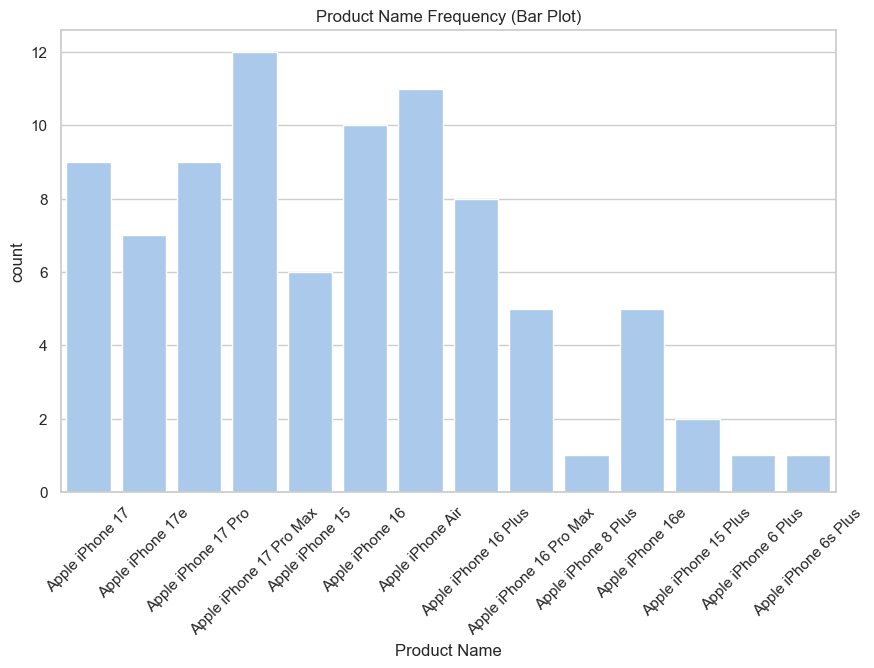

In [40]:

# Product Name	
plt.figure(figsize=(10,6))
sns.countplot(x='Product Name', data=df)
plt.title("Product Name Frequency (Bar Plot)")
plt.xticks(rotation=45)
plt.show()

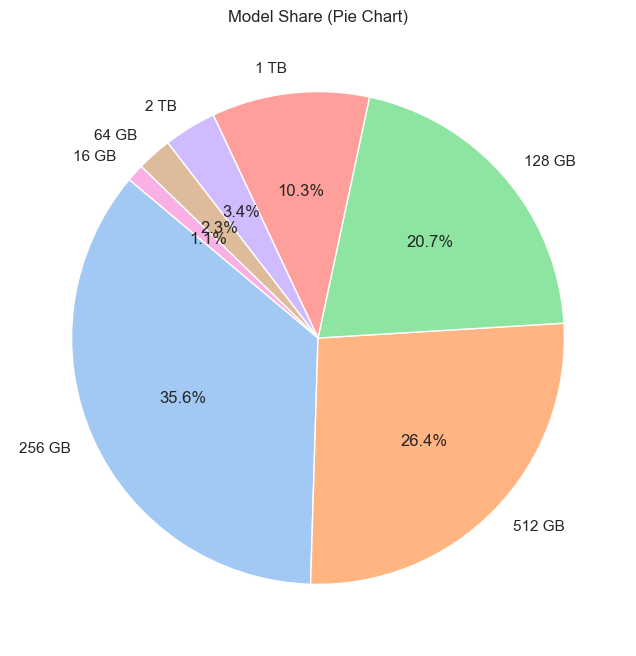

In [41]:

# ROM
model_counts = df['ROM'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(model_counts, labels=model_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Model Share (Pie Chart)")
plt.show()

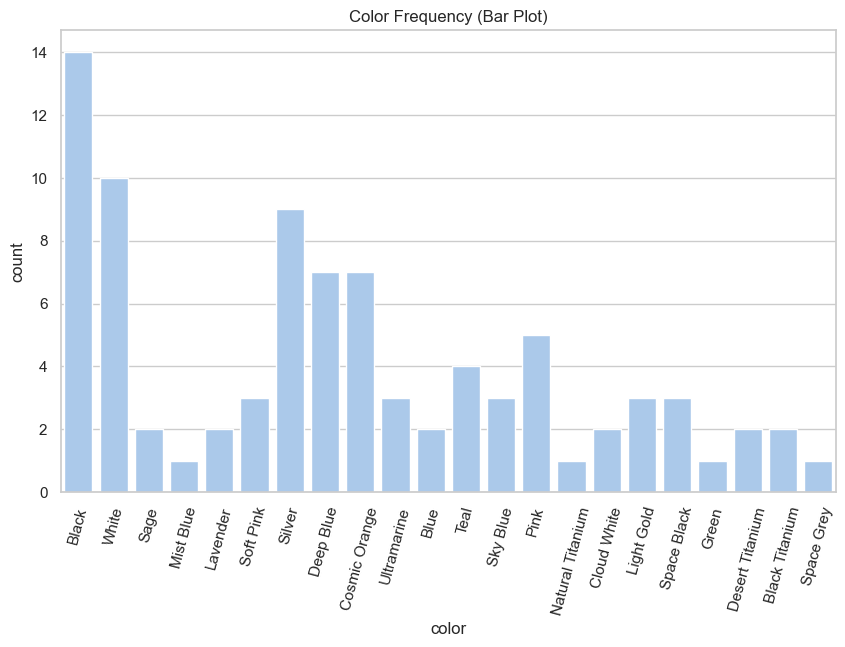

In [42]:
#  Color

plt.figure(figsize=(10,6))
sns.countplot(x='color', data=df)
plt.title("Color Frequency (Bar Plot)")
plt.xticks(rotation=75)
plt.show()

In [43]:
df.columns

Index(['Product Name', 'Price', 'ROM', 'Display', 'Camera', 'Processor',
       'color'],
      dtype='object')

Text(0.5, 1.0, 'Distribution of Display Size (Histogram)')

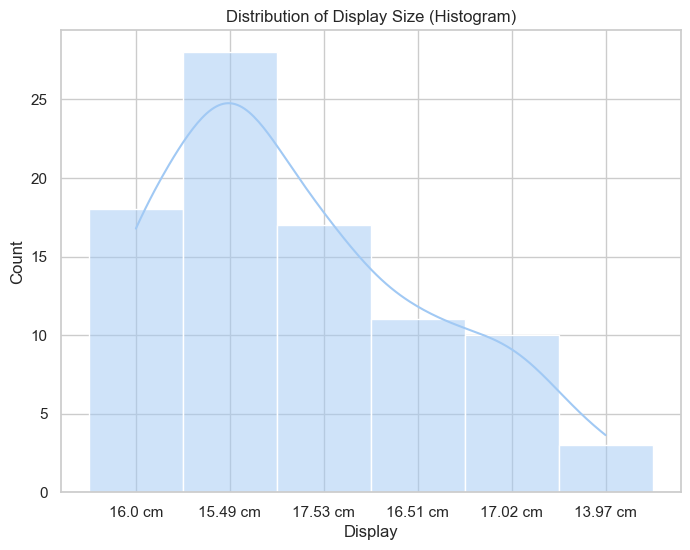

In [44]:

#Display CM

plt.figure(figsize=(8,6))
sns.histplot(df['Display'], bins=10, kde=True)
plt.title("Distribution of Display Size (Histogram)")#

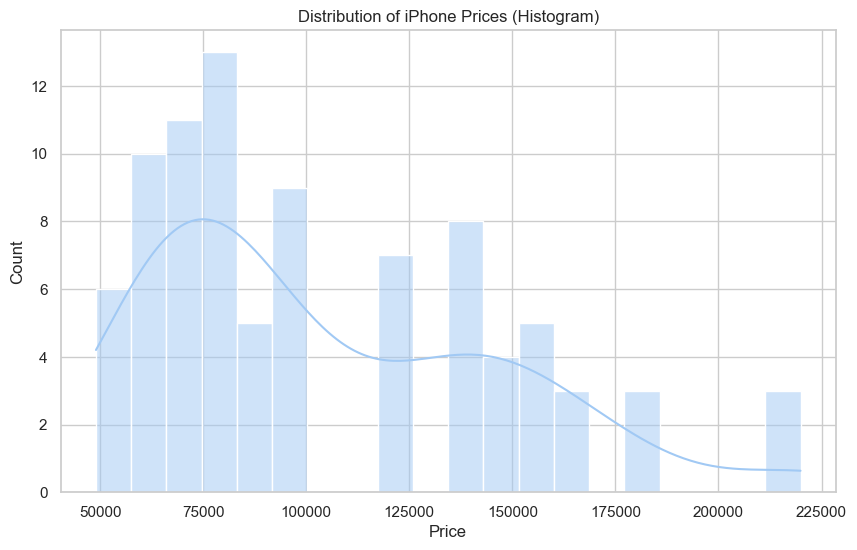

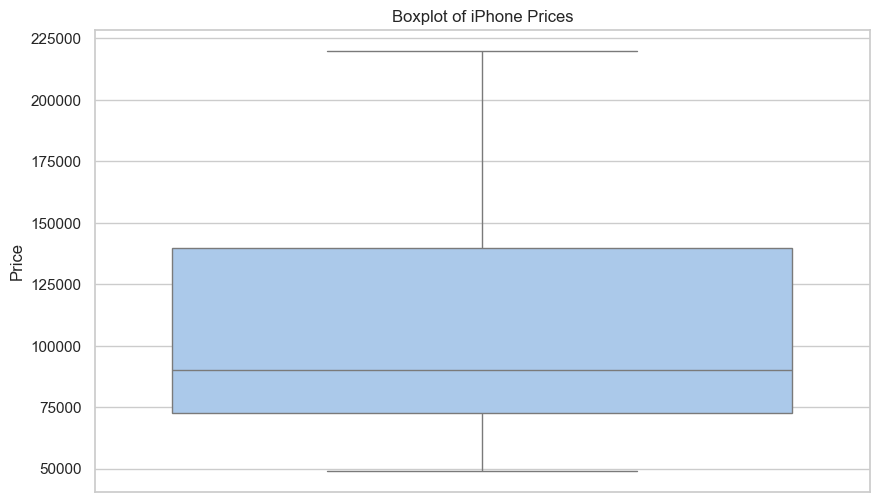

In [45]:
# Price INR

plt.figure(figsize=(10,6))
sns.histplot(df['Price'], bins=20, kde=True)
plt.title("Distribution of iPhone Prices (Histogram)")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(y='Price', data=df)
plt.title("Boxplot of iPhone Prices")
plt.show()

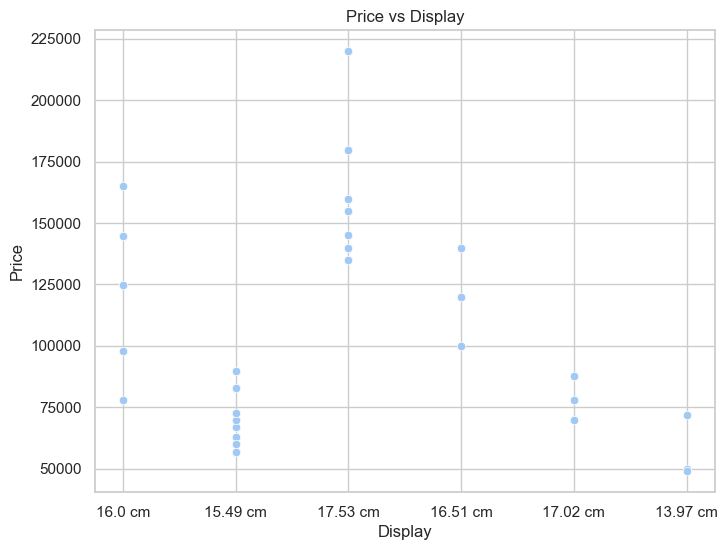

In [46]:
# price vs ratings
plt.figure(figsize=(8,6))
sns.scatterplot(x='Display', y='Price', data=df)
plt.title("Price vs Display")
plt.show()

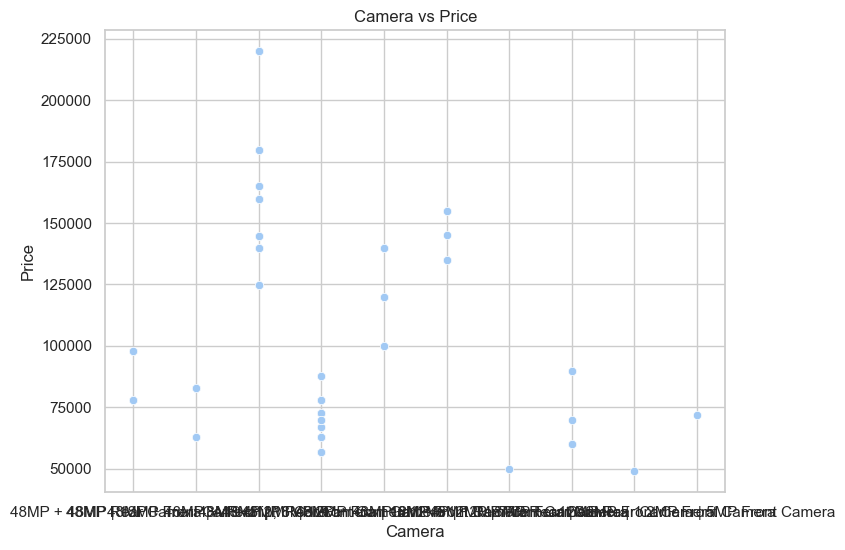

In [47]:
# ratings vs display
plt.figure(figsize=(8,6))
sns.scatterplot(x='Camera', y='Price', data=df)
plt.title("Camera vs Price")
plt.show()

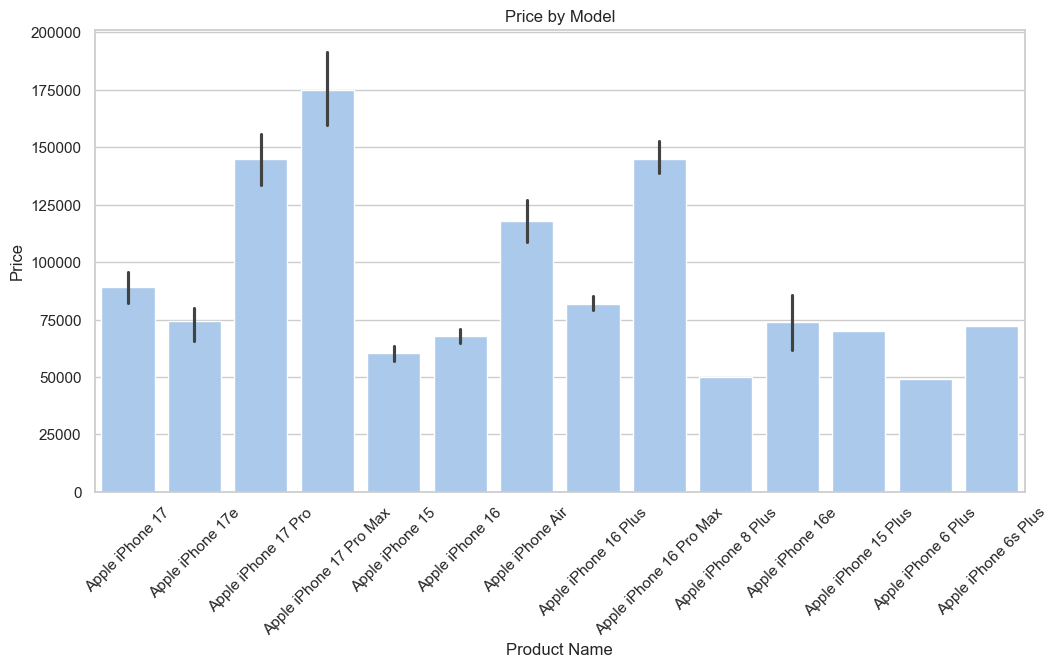

In [48]:

# model vs price
plt.figure(figsize=(12,6))
sns.barplot(x='Product Name', y='Price', data=df)
plt.title("Price by Model")
plt.xticks(rotation=45)
plt.show()

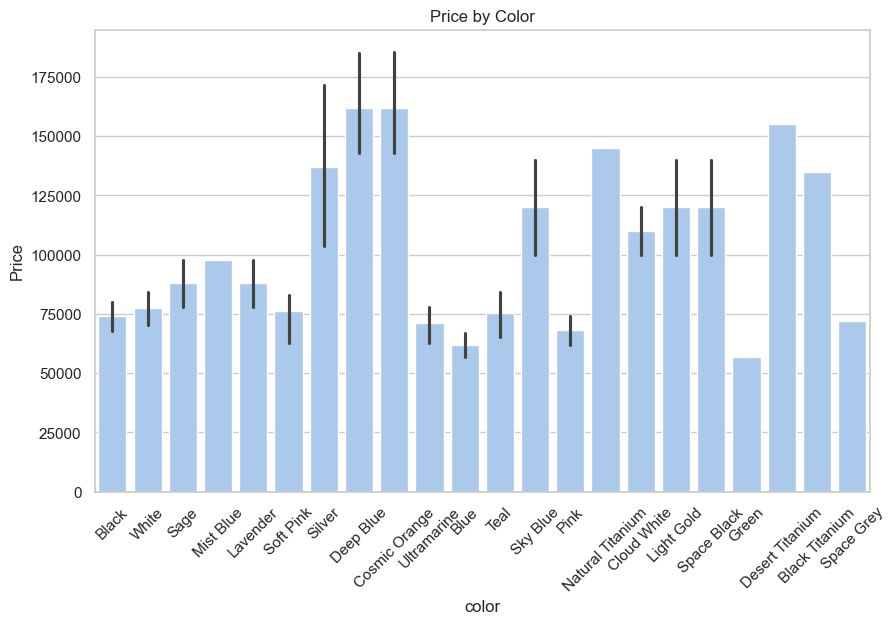

In [49]:

# color vs price
plt.figure(figsize=(10,6))
sns.barplot(x='color', y='Price', data=df)
plt.title("Price by Color")
plt.xticks(rotation=45)
plt.show()

In [50]:
df.to_csv("webscraped.csv", index=False)
